# Reduced states on a Gaussian square lattice

A `size x size` square lattice of `GfPEPS` nodes from `FreeFermion/GfPEPS.py`: one node per
site, carrying `ext_dim` external (physical) Majorana modes and one `bond_dim`-Majorana bond
to its right and down neighbour, with the covariance drawn from `RandPureCov`, so every node
starts **pure**.

Two operations are easy to confuse, and they behave differently:

| operation | what it does to the modes | purity |
|---|---|---|
| contract a bond | inner product with the fermionic EPR state on the bond (`contract_sites`) | pure $\to$ pure |
| trace out a subsystem | keep the sub-block of the covariance (partial trace) | pure $\to$ mixed |

So *contract everything, then trace* is exact, while *cut the bonds first, then contract* is
the tensor-network approximation.


## 1. What the module provides

The mode bookkeeping lives in `GfPEPS` now:

* `state.contract_all()` — contract every bond into one node and return
  `(state, labels)`, where `labels[(node, mode)]` is the mode index in the result;
* `state.partial_trace(sites)` — the exact reduced state of a set of nodes (contract
  everything, then trace out the rest);
* `GfPEPS.from_covariances` / `from_global_covariance` / `from_hamiltonian` /
  `product_state` — public constructors instead of the private `_from_data`;
* `state[node]` — the covariance of a node as blocks keyed by leg (`state[node][a, b]`),
  so a virtual bond and the matrix entries that belong to it cannot drift apart;
* `purity`, `entropy`, `occupations`, `is_pure` (`FreeFermion/linalg.py`) — diagnostics of a covariance.

Only two helpers are local to this notebook: the lattice builder, and
`cut_patch_covariance`, the *cut the bonds first* approximation that the module deliberately
does not provide (it is not the exact reduced state).


In [1]:
import torch
from torch import Tensor

from base import CUDA
from FreeFermion.GfPEPS import Bond, Graph, GfPEPS
from FreeFermion.linalg import RandPureCov, entropy, is_pure, occupations, purity


def square_lattice(size: int, ext_dim: int = 2, bond_dim: int = 2,
                   seed: int | None = None) -> GfPEPS:
    '''
    open square lattice of size x size nodes, one node per site, a bond to the
    right and to the down neighbour, and a random pure covariance on every node.
    Args:
        size: number of rows and columns.
        ext_dim: external Majorana modes per site.
        bond_dim: Majorana modes per bond.
        seed: optional torch seed for the random covariances.
    Returns:
        The GfPEPS with size**2 nodes.
    '''
    if seed is not None:
        torch.manual_seed(seed)
    edges = []
    for row in range(size):
        for column in range(size):
            node = row * size + column
            if column + 1 < size:
                edges.append(Bond(node, node + 1, bond_dim))
            if row + 1 < size:
                edges.append(Bond(node, node + size, bond_dim))
    return GfPEPS(Graph(size * size, tuple(edges)), [ext_dim] * (size * size))


def cut_patch_covariance(state: GfPEPS, sites: list[int]) -> Tensor:
    '''
    the tensor-network approximation: cut every bond that leaves the patch before
    contracting, i.e. keep on each patch node only its external modes and the bond
    blocks that stay inside, and then contract the patch alone.  Selecting the legs
    of a node is enough, because its blocks are keyed by leg: dropping a bond drops
    its blocks and the entries of the matrix together.
    Args:
        state: the Gaussian network.
        sites: the original node labels of the patch.
    Returns:
        The covariance of the patch, square of size 2 * ext_dim * len(sites).
    '''
    inside = sorted(sites)
    bonds = [bond for bond in state.graph.edges
             if bond.first in inside and bond.second in inside]
    tensors, ext_dim = [], []
    for node in inside:
        legs = [None] + [bond for bond in state.graph.bonds(node) if bond in bonds]
        tensors.append(state[node].assemble(legs))
        ext_dim.append(state.ext_dim[node])
    labels = {node: index for index, node in enumerate(inside)}
    edges = tuple(Bond(labels[bond.first], labels[bond.second], bond.bond_dim)
                  for bond in bonds)
    return GfPEPS.from_covariances(Graph(len(inside), edges), ext_dim,
                                   tensors).partial_trace(list(range(len(inside))))


## 2. Contracting the bonds keeps the state pure

In [2]:
size = 3
sites = [row * size + column for row in range(size) for column in range(size)]
lattice = square_lattice(size=size, ext_dim=2, bond_dim=2, seed=0)
print(f'{size}x{size} lattice: {len(sites)} nodes, {len(lattice.graph.edges)} bonds, '
      f'{sum(lattice.ext_dim)} external Majorana modes')
print(f'each node is pure          : is_pure = {is_pure(lattice.tensors[0])}, '
      f'purity = {purity(lattice.tensors[0]):.15f}')

contracted, labels = lattice.contract_all()
print(f'all bonds contracted       : {tuple(contracted.tensors[0].shape)}, '
      f'is_pure = {is_pure(contracted.tensors[0])}  <- still pure')
print('  labels[(0, 1)] =', labels[(0, 1)], ' labels[(8, 1)] =', labels[(8, 1)])

# the order of the internal bond contractions does not matter
backwards, labels_backwards = lattice.contract_all(from_end=True)
print(f'contracting back to front  : is_pure = {is_pure(backwards.tensors[0])} '
      f'(its labels record the new mode order)')
print(f'whole lattice, both orders : |diff| = '
      f'{float((lattice.partial_trace(sites) - lattice.partial_trace(sites, from_end=True)).abs().max()):.1e}')


3x3 lattice: 9 nodes, 12 bonds, 18 external Majorana modes
each node is pure          : is_pure = True, purity = 0.999999999999999
all bonds contracted       : (18, 18), is_pure = True  <- still pure
  labels[(0, 1)] = 1  labels[(8, 1)] = 17
contracting back to front  : is_pure = True (its labels record the new mode order)
whole lattice, both orders : |diff| = 4.2e-16


## 3. Tracing out the environment makes the patch mixed

`partial_trace` contracts **all** bonds first (pure), then keeps the sub-block of the patch,
i.e. traces out the rest. The naive route cuts the bonds that leave the patch before
contracting, and differs.

Every patch below comes with its own picture of the 3x3 lattice: a filled node carries the
modes that are kept, a solid bond stays inside the patch and is contracted, and a dashed bond
leaves the patch, so the naive route drops the blocks of its inner legs.


In [3]:
import matplotlib.pyplot as plt


def draw_patches(state: GfPEPS, size: int, patches: list[tuple[list[int], str]],
                 order: list[int] | None = None) -> None:
    '''
    one figure with one panel per patch: a filled node carries the modes that are
    kept, a solid bond stays inside the patch, a dashed bond leaves it.
    Args:
        state: the Gaussian network; only its graph is read.
        size: number of rows and columns of the square lattice.
        patches: (patch, label) of every panel, the label is the title.
        order: optional walk through the sites; a node is then numbered by its
            position in it instead of by its label.
    '''
    step = {} if order is None else {node: index + 1 for index, node in enumerate(order)}

    def place(node: int) -> tuple[int, int]:
        return node % size, size - 1 - node // size

    figure, panels = plt.subplots(1, len(patches), squeeze=False,
                                  figsize=(3.0 * len(patches), 3.2))
    for axis, (patch, name) in zip(panels[0], patches):
        kept = set(patch)
        for bond in state.graph.edges:
            x0, y0 = place(bond.first)
            x1, y1 = place(bond.second)
            inside = bond.first in kept and bond.second in kept
            axis.plot([x0, x1], [y0, y1], zorder=1,
                      color='tab:blue' if inside else '0.75',
                      linestyle='-' if inside else '--',
                      linewidth=2.4 if inside else 1.1)
        for node in range(state.graph.num_nodes):
            axis.scatter(*place(node), s=340, zorder=2,
                         color='tab:blue' if node in kept else 'white',
                         edgecolor='tab:blue' if node in kept else '0.55', linewidth=1.4)
            axis.text(*place(node), str(step.get(node, node)), zorder=3,
                      ha='center', va='center', color='white' if node in kept else '0.35',
                      fontsize=9 if step else 10)
        axis.set_title(name, fontsize=11)
        axis.set_xlim(-0.6, size - 0.4)
        axis.set_ylim(-0.6, size - 0.4)
        axis.set_aspect('equal')
        axis.axis('off')
    figure.tight_layout()
    plt.show()


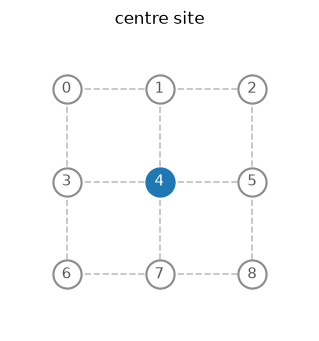

centre site (1 sites, 2 modes)
  exact  : purity = 0.5001, entropy = 0.6931, occupations = [0.49334]
  naive  : purity = 0.5087, |diff vs exact| = 0.1454


In [4]:
patch = [4]
draw_patches(lattice, size, [(patch, 'centre site')])

exact = lattice.partial_trace(patch)
naive = cut_patch_covariance(lattice, patch)
print(f'centre site ({len(patch)} sites, {exact.shape[0]} modes)')
print(f'  exact  : purity = {purity(exact):.4f}, entropy = {entropy(exact):.4f}, '
      f'occupations = {[round(float(x), 5) for x in occupations(exact)]}')
print(f'  naive  : purity = {purity(naive):.4f}, |diff vs exact| = '
      f'{float((exact - naive).abs().max()):.4f}')


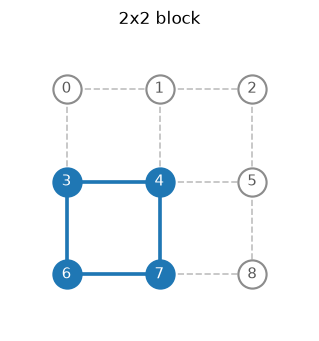

2x2 block (4 sites, 8 modes)
  exact  : purity = 0.3443, entropy = 1.2509, occupations = [0.45728, 0.1752, 0.01956, 0.0001]
  naive  : purity = 0.2911, |diff vs exact| = 0.2493


In [5]:
patch = [3, 4, 6, 7]
draw_patches(lattice, size, [(patch, '2x2 block')])

exact = lattice.partial_trace(patch)
naive = cut_patch_covariance(lattice, patch)
print(f'2x2 block ({len(patch)} sites, {exact.shape[0]} modes)')
print(f'  exact  : purity = {purity(exact):.4f}, entropy = {entropy(exact):.4f}, '
      f'occupations = {[round(float(x), 5) for x in occupations(exact)]}')
print(f'  naive  : purity = {purity(naive):.4f}, |diff vs exact| = '
      f'{float((exact - naive).abs().max()):.4f}')


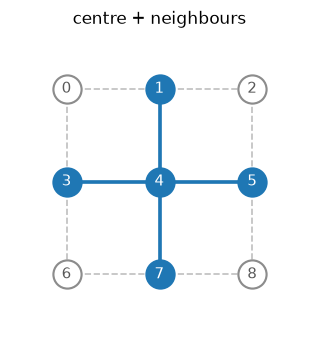

centre + neighbours (5 sites, 10 modes)
  exact  : purity = 0.2684, entropy = 1.6597, occupations = [0.37075, 0.23549, 0.06697, 0.05352, 0.0]
  naive  : purity = 0.0701, |diff vs exact| = 0.5933


In [6]:
patch = [1, 3, 4, 5, 7]
draw_patches(lattice, size, [(patch, 'centre + neighbours')])

exact = lattice.partial_trace(patch)
naive = cut_patch_covariance(lattice, patch)
print(f'centre + neighbours ({len(patch)} sites, {exact.shape[0]} modes)')
print(f'  exact  : purity = {purity(exact):.4f}, entropy = {entropy(exact):.4f}, '
      f'occupations = {[round(float(x), 5) for x in occupations(exact)]}')
print(f'  naive  : purity = {purity(naive):.4f}, |diff vs exact| = '
      f'{float((exact - naive).abs().max()):.4f}')


## 4. Growing the patch back to the whole lattice

The mixedness and the entropy come from the modes that are traced out, so they shrink as the
patch grows and vanish when the patch is the whole lattice (nothing is traced out).


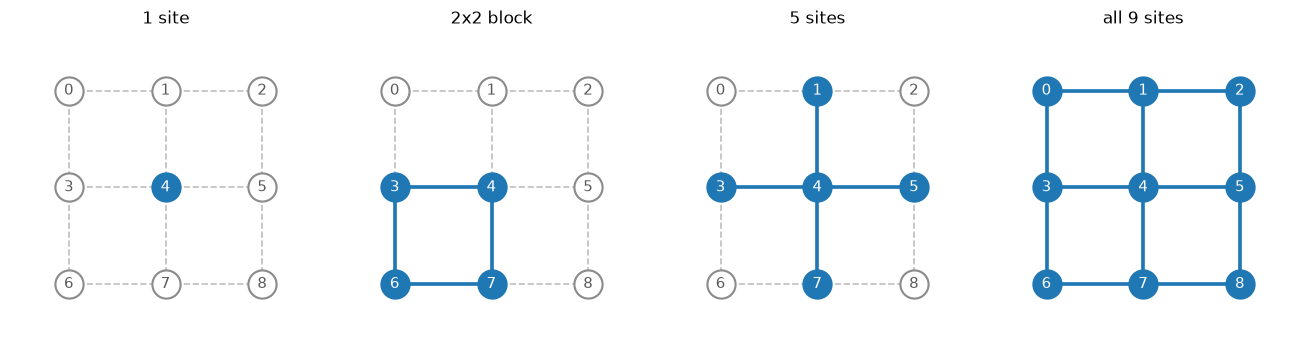

       patch  modes    purity   entropy   occupations
      1 site      2    0.5001    0.6931   [0.4933]
   2x2 block      8    0.3443    1.2509   [0.4573, 0.1752, 0.0196, 0.0001]
     5 sites     10    0.2684    1.6597   [0.3707, 0.2355, 0.067, 0.0535, 0.0]
 all 9 sites     18    1.0000    0.0000   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, -0.0, -0.0]


In [7]:
shapes = [([4], '1 site'), ([3, 4, 6, 7], '2x2 block'),
          ([1, 3, 4, 5, 7], '5 sites'), (sites, 'all 9 sites')]
draw_patches(lattice, size, shapes)

print(f'{"patch":>12} {"modes":>6} {"purity":>9} {"entropy":>9}   occupations')
for patch, name in shapes:
    exact = lattice.partial_trace(patch)
    print(f'{name:>12} {exact.shape[0]:>6} {purity(exact):>9.4f} {entropy(exact):>9.4f}   '
          f'{[round(float(x), 4) for x in occupations(exact)]}')


## 5. A bigger lattice: growing the patch along a snake

The patches of section 3 are small enough to look at one by one. On a 6x6 lattice the patch can be
grown site by site instead, and the growth order matters: the snake stays compact while a random
order makes a scattered patch of the same size. Each cell below is one step of that experiment.


`snake_order` walks the lattice row by row, alternating the direction, so every new site touches
the previous ones. `sweep` contracts the network once and then reads the entropy and the cut size
of every prefix of that order out of the same covariance, which is what makes the whole experiment
cost one contraction per seed.

In [8]:
import time

import numpy as np


def snake_order(size: int) -> list[int]:
    '''
    the sites in boustrophedon order: row 0 left to right, row 1 right to left, and so
    on, so that consecutive sites are neighbours.
    Args:
        size: number of rows and columns.
    Returns:
        The site labels in the order the snake visits them.
    '''
    order = []
    for row in range(size):
        columns = range(size) if row % 2 == 0 else reversed(range(size))
        order += [row * size + column for column in columns]
    return order


def sweep(network: GfPEPS, order: list[int]) -> tuple[np.ndarray, np.ndarray]:
    '''
    entropy and cut size of the first n sites of the given order, for every n, out of
    one contraction of the whole network.
    Args:
        network: the Gaussian network.
        order: the site labels in the order the patch grows.
    Returns:
        (entropies, crossings), index n-1 for a patch of the first n sites; a crossing
        is a bond with exactly one end in the patch.
    '''
    state, labels = network.contract_all()
    covariance = state.tensors[0]
    entropies, crossings = [], []
    for count in range(1, network.graph.num_nodes + 1):
        kept = set(order[:count])
        modes = [labels[(node, mode)] for node in sorted(kept)
                 for mode in range(network.ext_dim[node])]
        entropies.append(entropy(covariance[modes][:, modes]))
        crossings.append(sum(1 for bond in network.graph.edges
                             if (bond.first in kept) != (bond.second in kept)))
    return np.array(entropies), np.array(crossings)


Eight seeds, two growth orders and all 36 patch sizes. The snake order is the same for every
seed; the scattered orders are random permutations, one per seed.

In [9]:
grid, seeds, half = 6, 8, 18
lattice6 = square_lattice(grid, seed=0)
snake = snake_order(grid)
scattered = [list(np.random.default_rng(seed).permutation(grid * grid))
             for seed in range(seeds)]

start = time.perf_counter()
on_snake = [sweep(square_lattice(grid, seed=seed), snake) for seed in range(seeds)]
on_scattered = [sweep(square_lattice(grid, seed=seed), order)
                for seed, order in enumerate(scattered)]
print(f'{seeds} seeds x 2 orders x {grid * grid} patch sizes in '
      f'{time.perf_counter() - start:.1f} s')


8 seeds x 2 orders x 36 patch sizes in 2.0 s


The picture numbers the sites in the order the snake visits them. At half filling the snake cuts
the 6 bonds between row 3 and row 4, while a scattered patch cuts about 33: a compact patch has a
much smaller boundary, and that is where its smaller entropy comes from.

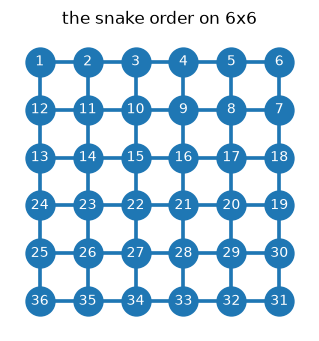

half filling (18 sites): the snake cuts 6 bonds, a random patch cuts 33.5


In [10]:
title = f'the snake order on {grid}x{grid}'
draw_patches(lattice6, grid, [(list(range(grid * grid)), title)], order=snake)
print(f'half filling ({half} sites): the snake cuts {on_snake[0][1][half - 1]} bonds, '
      f'a random patch cuts {np.mean([crossings[half - 1] for _, crossings in on_scattered]):.1f}')


`S(n)` for both orders, against the upper bound `min(n, N-n) ln 2`; a patch has as much entropy as
its complement, which is why both orders turn over at half filling. The scattered patch rises to a
rounded peak, the snake forms a plateau set by its cut, and both fall to zero when the patch is the
whole lattice and there is nothing left to trace out.

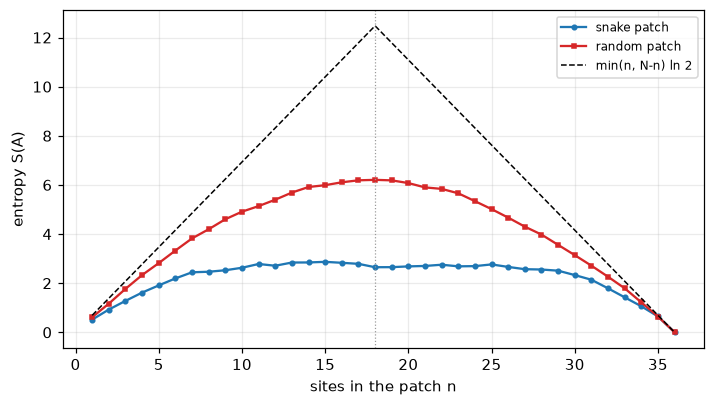

  n   snake   random   bound
  1  0.5176   0.6158  0.6931
  6  2.1942   3.3293  4.1589
 12  2.7097   5.3983  8.3178
 18  2.6497   6.2066 12.4766
 24  2.6945   5.3398  8.3178
 30  2.3300   3.1417  4.1589
 35  0.6471   0.6429  0.6931
 36  0.0000   0.0000  0.0000


In [11]:
checkerboard = [node for node in range(grid * grid)
                if (node // grid + node % grid) % 2 == 0]
checkerboard_entropy = np.array([sweep(square_lattice(grid, seed=seed), checkerboard)[0][half - 1]
                                 for seed in range(seeds)])

counts = np.arange(1, grid * grid + 1)
snake_entropy = np.mean([values for values, _ in on_snake], axis=0)
scattered_entropy = np.mean([values for values, _ in on_scattered], axis=0)

figure, axis = plt.subplots(figsize=(6.6, 3.8))
axis.plot(counts, snake_entropy, 'o-', ms=3, color='tab:blue', label='snake patch')
axis.plot(counts, scattered_entropy, 's-', ms=3, color='tab:red', label='random patch')
axis.plot(counts, np.minimum(counts, grid * grid - counts) * np.log(2), 'k--', lw=1.0,
          label='min(n, N-n) ln 2')
axis.axvline(half, color='0.6', lw=0.8, ls=':')
axis.set_xlabel('sites in the patch n')
axis.set_ylabel('entropy S(A)')
axis.legend(fontsize=8)
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

print(f'{"n":>3} {"snake":>7} {"random":>8} {"bound":>7}')
for count in (1, grid, 2 * grid, 3 * grid, 4 * grid, 5 * grid, grid * grid - 1, grid * grid):
    index = count - 1
    print(f'{count:>3} {snake_entropy[index]:>7.4f} {scattered_entropy[index]:>8.4f} '
          f'{np.minimum(count, grid * grid - count) * np.log(2):>7.4f}')


That bound is the **Page curve**, the average entropy of a subsystem of a Haar random pure state.
A random pure *Gaussian* state follows a lower curve of the same shape, the Gaussian Page curve of
Bianchi, Hackl and Kieburg (Phys. Rev. B 103, L241118 (2021), eq. (6)), which is compared below with
the same curve measured on `RandPureCov` states. The tensor network sits below both: its entropy is
set by the bonds it cuts, an area law, which is the `Area` piece of the island formula
`S = min[Area/4G + S_bulk]`, while the Page curve is its `S_bulk` piece. The turn at half the
lattice is the same `min`: past half filling the entropy of the patch is the entropy of its
complement.

Only the dashed Page curve is a bound. The Gaussian Page curve is an average over states at a fixed
bipartition, not a bound, so a patch of a given state may sit above it: the star below is one
particular patch, the checkerboard, averaged over the same seeds, and its spread straddles the
Gaussian average; section 6 pushes past it by choosing the patch inside a single state.

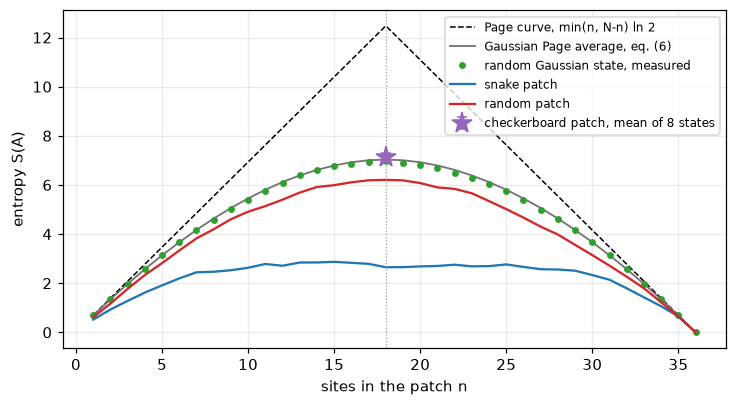

  n    Page  GaussPage  Gaussian   snake   random
  6  4.1589     3.6668    3.6792  2.1942   3.3293
 12  8.3178     6.1153    6.0835  2.7097   5.3983
 18 12.4766     7.0318    6.9796  2.6497   6.2066
 24  8.3178     6.1153    6.0397  2.6945   5.3398
 30  4.1589     3.6668    3.6688  2.3300   3.1417
the checkerboard patch, one patch averaged over 8 states, has S = 7.1466, from 6.9020 to 7.4485: the states straddle the exact Gaussian Page average 7.0318, which averages over states and is therefore not a bound.
at half filling, in units of the Page value: Gaussian Page 0.564, random Gaussian state 0.559, snake patch 0.212, random patch 0.497


In [12]:
from scipy.special import digamma


def gaussian_page(num_modes: int, subsystem: int) -> float:
    '''
    average entanglement entropy of a subsystem of a random pure Gaussian state,
    Bianchi-Hackl-Kieburg, Phys. Rev. B 103, L241118 (2021), eq. (6), in nats.
    Args:
        num_modes: the total number of modes N.
        subsystem: the modes of the subsystem N_A.
    Returns:
        The average entropy over the Gaussian states of N modes.
    '''
    return ((num_modes - 0.5) * digamma(2 * num_modes)
            + (0.5 + subsystem - num_modes) * digamma(2 * num_modes - 2 * subsystem)
            + (0.25 - subsystem) * digamma(num_modes)
            - 0.25 * digamma(num_modes - subsystem) - subsystem)


modes, repeats = grid * grid, 8        # one complex mode per site
pure_gaussian = []
for seed in range(repeats):
    torch.manual_seed(seed)
    gamma = RandPureCov(2 * modes)
    pure_gaussian.append([entropy(gamma[:2 * count, :2 * count]) for count in counts])
pure_gaussian = np.mean(pure_gaussian, axis=0)

page = np.minimum(counts, grid * grid - counts) * np.log(2)
gaussian_curve = np.array([gaussian_page(modes, min(count, grid * grid - count))
                           for count in counts])

figure, axis = plt.subplots(figsize=(6.8, 3.8))
axis.plot(counts, page, 'k--', lw=1.0, label='Page curve, min(n, N-n) ln 2')
axis.plot(counts, gaussian_curve, color='0.45', lw=1.2, label='Gaussian Page average, eq. (6)')
axis.plot(counts, pure_gaussian, 'o', ms=3.5, color='tab:green',
          label='random Gaussian state, measured')
axis.plot(counts, snake_entropy, color='tab:blue', label='snake patch')
axis.plot(counts, scattered_entropy, color='tab:red', label='random patch')
axis.errorbar([half], [checkerboard_entropy.mean()], yerr=[checkerboard_entropy.std()],
              fmt='*', ms=14, color='tab:purple', capsize=3,
              label=f'checkerboard patch, mean of {seeds} states')
axis.axvline(half, color='0.6', lw=0.8, ls=':')
axis.set_xlabel('sites in the patch n')
axis.set_ylabel('entropy S(A)')
axis.legend(fontsize=8)
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

print(f'{"n":>3} {"Page":>7} {"GaussPage":>10} {"Gaussian":>9} {"snake":>7} {"random":>8}')
for count in (grid, 2 * grid, 3 * grid, 4 * grid, 5 * grid):
    index = count - 1
    print(f'{count:>3} {page[index]:>7.4f} {gaussian_curve[index]:>10.4f} '
          f'{pure_gaussian[index]:>9.4f} {snake_entropy[index]:>7.4f} '
          f'{scattered_entropy[index]:>8.4f}')
print(f'the checkerboard patch, one patch averaged over {seeds} states, has S = '
      f'{checkerboard_entropy.mean():.4f}, from {checkerboard_entropy.min():.4f} to '
      f'{checkerboard_entropy.max():.4f}: the states straddle the exact Gaussian Page average '
      f'{gaussian_curve[half - 1]:.4f}, which averages over states and is therefore not a bound.')
print(f'at half filling, in units of the Page value: Gaussian Page '
      f'{gaussian_curve[half - 1] / page[half - 1]:.3f}, random Gaussian state '
      f'{pure_gaussian[half - 1] / page[half - 1]:.3f}, snake patch '
      f'{snake_entropy[half - 1] / page[half - 1]:.3f}, random patch '
      f'{scattered_entropy[half - 1] / page[half - 1]:.3f}')


Is the cut alone enough to fix the entropy? Growing the bond dimension at half filling makes the
cut carry more modes, and the entropy grows with it, but the entropy per cut mode falls from 0.90 to
0.39: the cut gives the area-law tendency, not a coefficient.

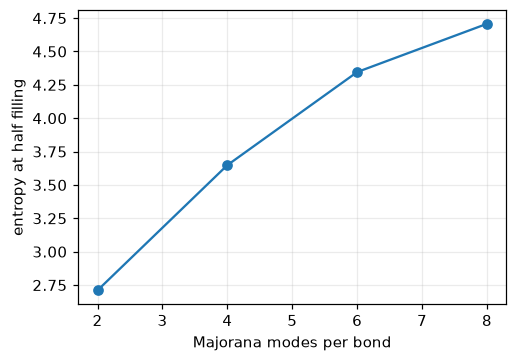

half filling against the bond dimension, snake patch
  bond_dim 2: S(half) = 2.711, the cut carries 6 Majorana modes (3.0 complex), S per cut mode = 0.904
  bond_dim 4: S(half) = 3.648, the cut carries 12 Majorana modes (6.0 complex), S per cut mode = 0.608
  bond_dim 6: S(half) = 4.346, the cut carries 18 Majorana modes (9.0 complex), S per cut mode = 0.483
  bond_dim 8: S(half) = 4.707, the cut carries 24 Majorana modes (12.0 complex), S per cut mode = 0.392


In [13]:
bond_dims, repeats = (2, 4, 6, 8), 4
half_entropy, lines = [], ['half filling against the bond dimension, snake patch']
for bond_dim in bond_dims:
    values = [sweep(square_lattice(grid, bond_dim=bond_dim, seed=seed), snake)[0][half - 1]
              for seed in range(repeats)]
    half_entropy.append(np.mean(values))
    cut = grid // 2 * bond_dim
    lines.append(f'  bond_dim {bond_dim}: S(half) = {np.mean(values):.3f}, the cut carries {cut} '
                 f'Majorana modes ({cut / 2} complex), S per cut mode = '
                 f'{np.mean(values) / (cut / 2):.3f}')

figure, axis = plt.subplots(figsize=(4.8, 3.4))
axis.plot(bond_dims, half_entropy, 'o-', color='tab:blue')
axis.set_xlabel('Majorana modes per bond')
axis.set_ylabel('entropy at half filling')
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

for line in lines:
    print(line)


## 6. The largest patch of a given size

Section 5 fixes the growth order and varies the size; here the size is fixed at half filling, 18 of
the 36 sites, and the question is how much the *shape* of a patch matters. All the patches below are
cut out of the same state, and the two Page values of section 5 are drawn with them for comparison.


In [14]:
state_half, labels_half = lattice6.contract_all()
covariance_half = state_half.tensors[0]
node_modes = {node: [labels_half[(node, mode)] for mode in range(lattice6.ext_dim[node])]
              for node in range(grid * grid)}


def patch_entropy(patch: list[int]) -> float:
    '''
    entropy of a patch, read out of the covariance contracted once above.
    Args:
        patch: the site labels of the patch.
    Returns:
        The entropy of the reduced state of the patch, in nats.
    '''
    modes = [mode for node in sorted(set(patch)) for mode in node_modes[node]]
    return entropy(covariance_half[modes][:, modes])


def patch_cut(patch: list[int]) -> int:
    '''
    number of bonds with exactly one end in the patch.
    Args:
        patch: the site labels of the patch.
    Returns:
        The number of bonds the patch cuts.
    '''
    kept = set(patch)
    return sum(1 for bond in lattice6.graph.edges
               if (bond.first in kept) != (bond.second in kept))


def climb(start: list[int], rounds: int, seed: int) -> list[int]:
    '''
    greedy search for the patch of the same size with the largest entropy: propose a
    swap of one site for another and keep it when the entropy grows.
    Args:
        start: the patch to start from.
        rounds: number of proposed swaps.
        seed: seed of the random proposals.
    Returns:
        The best patch found.
    '''
    rng = np.random.default_rng(seed)
    best, best_value = sorted(start), patch_entropy(start)
    current, value = list(best), best_value
    for _ in range(rounds):
        gone = int(rng.choice(current))
        free = [node for node in range(grid * grid) if node not in current]
        trial = [node for node in current if node != gone] + [int(rng.choice(free))]
        trial_value = patch_entropy(trial)
        if trial_value > value:
            current, value = trial, trial_value
            if value > best_value:
                best, best_value = sorted(current), value
    return best


rows = list(range(half))
rng = np.random.default_rng(0)
scattered_half = [list(rng.permutation(grid * grid)[:half]) for _ in range(20)]
climbed = climb(list(rng.permutation(grid * grid)[:half]), rounds=400, seed=0)

print(f'{"patch":>20} {"cut bonds":>10} {"entropy":>9}')
for name, patch in [('three rows', rows), ('random, mean of 20', None),
                    ('checkerboard', checkerboard), ('greedy search', climbed)]:
    if patch is None:
        print(f'{name:>20} {"":>10} '
              f'{np.mean([patch_entropy(one) for one in scattered_half]):>9.4f}')
    else:
        print(f'{name:>20} {patch_cut(patch):>10} {patch_entropy(patch):>9.4f}')
print(f'{"Gaussian Page average":>20} {"":>10} {gaussian_curve[half - 1]:>9.4f}')
print(f'{"Page bound":>20} {"":>10} {page[half - 1]:>9.4f}')


               patch  cut bonds   entropy
          three rows          6    2.6996
  random, mean of 20               6.3698
        checkerboard         60    7.4485
       greedy search         42    7.9180
Gaussian Page average               7.0318
          Page bound              12.4766


The checkerboard cuts all 60 bonds, the most any 18 sites can, and
it beats both a compact patch and a random one. It is not the largest patch of this size though: the
greedy search finds patches that cut *fewer* bonds and still carry more entropy, because the entropy
is a property of the reduced spectrum and the cut is only a proxy for it.

Both patches on the right sit *above* the Gaussian Page average: 7.45 and 7.92 against 7.03, all
three numbers for the same state. The Gaussian Page curve is an average over states at a fixed
bipartition, not a bound, so a patch chosen inside one state is allowed to beat it; that state is
itself a high one, with a checkerboard patch above the 7.15 of section 5. Only ``min(n, N-n) ln 2``
is a bound, and nothing here comes close to it.


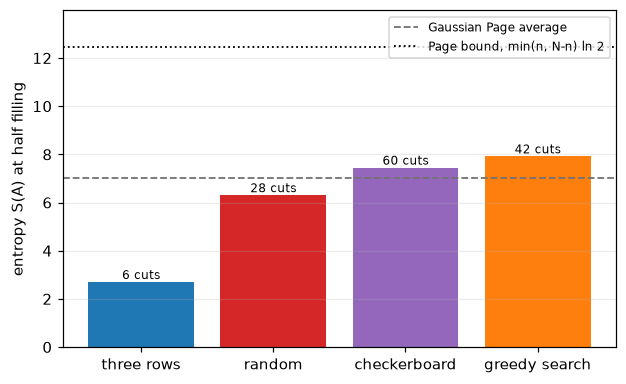

the greedy patch cuts 42 of 60 bonds and carries 1.13 times the Gaussian Page average, which is 0.63 of the Page bound.


In [15]:
names = ['three rows', 'random', 'checkerboard', 'greedy search']
patches = [rows, scattered_half[0], checkerboard, climbed]
values = [patch_entropy(patch) for patch in patches]

figure, axis = plt.subplots(figsize=(5.8, 3.6))
axis.bar(names, values, color=['tab:blue', 'tab:red', 'tab:purple', 'tab:orange'])
for position, (patch, value) in enumerate(zip(patches, values)):
    axis.text(position, value, f'{patch_cut(patch)} cuts', ha='center', va='bottom', fontsize=8)
axis.axhline(gaussian_curve[half - 1], color='0.45', lw=1.2, ls='--',
             label='Gaussian Page average')
axis.axhline(page[half - 1], color='k', lw=1.2, ls=':', label='Page bound, min(n, N-n) ln 2')
axis.set_ylim(0, page[half - 1] * 1.12)
axis.set_ylabel('entropy S(A) at half filling')
axis.legend(fontsize=8)
axis.grid(alpha=0.25, axis='y')
figure.tight_layout()
plt.show()

print(f'the greedy patch cuts {patch_cut(climbed)} of 60 bonds and carries '
      f'{patch_entropy(climbed) / gaussian_curve[half - 1]:.2f} times the Gaussian Page average, '
      f'which is {patch_entropy(climbed) / page[half - 1]:.2f} of the Page bound.')
